# 第四单元习题课- 问题1 （Python演示找错 ） 

1-way Repeated-Measures ANOVA 教学演示：基于 Pingouin

## 课堂目标

本 Notebook 用一个实际教学案例演示 **1-way repeated-measures ANOVA** 的完整流程：

1. 导入数据  
2. 理解 long-format 数据结构  
3. 描述统计与可视化  
4. 正态性检验  
5. 球形性检验  
6. repeated-measures ANOVA  
7. 事后比较  
8. APA 格式结果汇报  
9. 发现并修正常见代码错误  

---

## 案例背景

研究问题：

> 一种 8 周运动干预是否会改善学生的心肺适能评分？

同一批学生在三个时间点接受测量：

- `Pre`：干预前  
- `Post`：干预后  
- `Followup`：干预结束 4 周后  

因变量：

- `fitness_score`：心肺适能评分，数值越高表示适能越好  

实验设计：

- 一个组内因素：`time`
- 三个水平：`Pre`, `Post`, `Followup`
- 同一批被试重复测量

因此应使用：

```text
1-way repeated-measures ANOVA
```

In [45]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

# 1. 创建并导入示例数据

为了便于课堂演示，这里直接在 Notebook 中创建数据。  
实际研究中，也可以使用：
本数据共有 18 名学生，每名学生在 3 个时间点均有一次测量。

In [46]:
# 创建 long-format 数据
data = {
    "subject": (
        ["S01"] * 3 + ["S02"] * 3 + ["S03"] * 3 + ["S04"] * 3 + ["S05"] * 3 + ["S06"] * 3 +
        ["S07"] * 3 + ["S08"] * 3 + ["S09"] * 3 + ["S10"] * 3 + ["S11"] * 3 + ["S12"] * 3 +
        ["S13"] * 3 + ["S14"] * 3 + ["S15"] * 3 + ["S16"] * 3 + ["S17"] * 3 + ["S18"] * 3
    ),
    "time": ["Pre", "Post", "Followup"] * 18,
    "fitness_score": [
        62, 70, 68,
        58, 66, 64,
        65, 73, 71,
        60, 68, 66,
        55, 63, 61,
        67, 76, 74,
        61, 69, 68,
        59, 65, 64,
        64, 72, 70,
        57, 64, 63,
        66, 75, 73,
        63, 71, 69,
        56, 62, 60,
        68, 77, 75,
        62, 69, 67,
        60, 67, 65,
        65, 74, 72,
        58, 66, 64
    ]
}

df = pd.DataFrame(data)
df.head()

,subject,time,fitness_score
0,S01,Pre,62
1,S01,Post,70
2,S01,Followup,68
3,S02,Pre,58
4,S02,Post,66


# 2. 检查数据结构

Repeated-measures ANOVA 要求明确：

- 哪一列是被试编号：`subject`
- 哪一列是组内因素：`time`
- 哪一列是因变量：`fitness_score`

In [47]:
print(df.info())
print("\n每个时间点的样本量：")
print(df.groupby("time")["fitness_score"].count())

print("\n每个被试的测量次数：")
print(df.groupby("subject")["time"].count().head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   subject        54 non-null     object
 1   time           54 non-null     object
 2   fitness_score  54 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.4+ KB
None

每个时间点的样本量：
time
Followup    18
Post        18
Pre         18
Name: fitness_score, dtype: int64

每个被试的测量次数：
subject
S01    3
S02    3
S03    3
S04    3
S05    3
Name: time, dtype: int64


# 3. 描述统计

先查看每个时间点的均值、标准差和样本量。

In [48]:
desc = df.groupby("time")["fitness_score"].agg(["count", "mean", "std", "min", "max"])
desc

,count,mean,std,min,max
time,,,,,
Followup,18,67.444444,4.435448,60,75
Post,18,69.277778,4.547857,62,77
Pre,18,61.444444,3.868762,55,68


# 4. 简单可视化

可以先画出不同时间点的均值趋势。

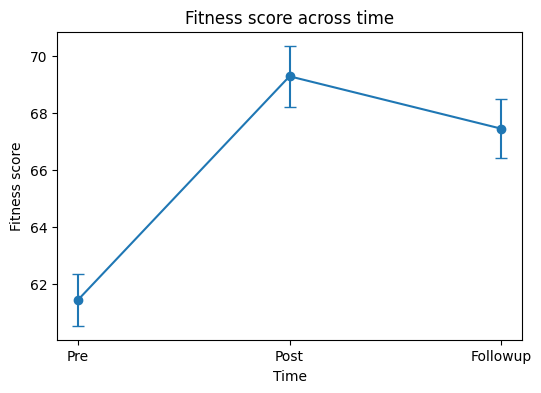

In [49]:
summary = df.groupby("time")["fitness_score"].agg(["mean", "std", "count"]).reset_index()
summary["se"] = summary["std"] / np.sqrt(summary["count"])

# 为了让时间顺序正确，手动指定顺序
time_order = ["Pre", "Post", "Followup"]
summary["time"] = pd.Categorical(summary["time"], categories=time_order, ordered=True)
summary = summary.sort_values("time")

plt.figure(figsize=(6, 4))
plt.errorbar(summary["time"], summary["mean"], yerr=summary["se"], marker="o", capsize=4)
plt.xlabel("Time")
plt.ylabel("Fitness score")
plt.title("Fitness score across time")
plt.show()

# 5. 正态性检验

## 统计假设

1-way repeated-measures ANOVA 的正态性主要指：

```text
每个重复测量条件下的因变量，或模型残差，应近似正态。
```

课堂上可先按每个时间点检查 `fitness_score` 的正态性。

Pingouin 常用函数：

```python
pg.normality(data=df, dv='fitness_score', group='time')
```

In [50]:
df.head()

,subject,time,fitness_score
0,S01,Pre,62
1,S01,Post,70
2,S01,Followup,68
3,S02,Pre,58
4,S02,Post,66


In [51]:
normality_result = pg.normality(
    data=df,
    dv="fitness_score",
    group="time"
)

normality_result

,W,pval,normal
time,,,
Pre,0.971471,0.824863,True
Post,0.968361,0.766365,True
Followup,0.970028,0.798212,True


## 正态性检验结果解释

一般可按如下规则：

```text
p > .05：未发现明显偏离正态
p < .05：可能偏离正态
```

注意：正态性检验在小样本下功效较低，在大样本下又可能过于敏感，因此还应结合直方图、QQ 图和研究背景判断。

# 6. 球形性检验

## 为什么不是方差齐性检验？

在 **组间设计 ANOVA** 中，通常检查方差齐性。  
但在 **重复测量 ANOVA** 中，更关键的是 **球形性假设**。

球形性大致指：

```text
各重复测量条件之间的差值方差相等。
```

如果重复测量因素只有 2 个水平，则球形性自动满足。  
本案例有 3 个时间点，因此需要检查球形性。

In [52]:
sphericity_result = pg.sphericity(
    data=df,
    dv="fitness_score",
    subject="subject",
    within="time"
)

sphericity_result

SpherResults(spher=False, W=np.float64(0.4280618311533932), chi2=np.float64(13.575802056364514), dof=2, pval=np.float64(0.00112733253179015))

# 7. 1-way repeated-measures ANOVA

使用 `pg.rm_anova()`。

关键参数：

```python
dv='fitness_score'       # 因变量
within='time'            # 组内因素
subject='subject'        # 被试编号
detailed=True            # 输出详细结果
correction='auto'        # 若球形性不满足，自动考虑 Greenhouse-Geisser 校正
effsize='np2'            # partial eta squared
```

In [53]:
aov = pg.rm_anova(
    data=df,
    dv="fitness_score",
    subject="subject",
    within="time",
    detailed=True,
    effsize="np2"
)

aov

,Source,SS,DF,MS,F,p_unc,p_GG_corr,np2,eps,sphericity,W_spher,p_spher
0,time,604.333333,2,302.166667,1062.793103,2.243067e-31,9.418995e-21,0.984256,0.636157,False,0.428062,0.001127
1,Error,9.666667,34,0.284314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 8. 事后比较

如果 ANOVA 显著，说明至少有两个时间点之间存在差异。  
但 ANOVA 本身不告诉我们是哪两个时间点不同，因此需要 post-hoc 比较。

对于重复测量设计，应使用配对比较，并指定：

```python
within='time'
subject='subject'
```

In [54]:
posthoc = pg.pairwise_tests(
    data=df,
    dv="fitness_score",
    subject="subject",
    within="time",
    padjust="bonf",
    effsize="hedges"
)

posthoc

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,time,Followup,Post,True,True,-20.282998,17.0,two-sided,2.378376e-13,7.135129e-13,bonf,2.489e+10,-0.399063
1,time,Followup,Pre,True,True,30.298515,17.0,two-sided,3.096077e-16,9.288232e-16,bonf,1.266e+13,1.409659
2,time,Post,Pre,True,True,35.985150,17.0,two-sided,1.735551e-17,5.206654e-17,bonf,1.896e+14,1.814137


# 习题课结果汇报： 
1. 参照APA 格式汇报 

2. 代码错误总结列表（给出错误的地方， 以及如何更正）

## 请在这里填写

1. time 因素 F 达到 1000 多，p<.0001，效果十分显著。事后检验认为每个时间的互相差异也很大 ——Followup 与 Post 的 (T=-20,p<.001)、Followup 与 Pre 的 (T=30,p<.001)、Post 与 Pre 的 (T=35,p<.001)。
2. 正态性检验那里，fitness_score大写首字母需要修正。
anova修改为rm_anova。
方差球性检验需要修改为sphericity。
between=“time”修改为within=“time”，并加上subject=“subject”

# 第四单元习题课- 问题2：  ANOVA理论 

完成PPT上的ANOVA表格。 
本研究采用 3 × 2 双因素组间实验设计，考察 睡眠时间 和 运动习惯 对大学生反应时的影响。

其中，因素 A 为 睡眠时间，包括 3 个水平：睡眠不足、睡眠正常、睡眠充足；因素 B 为 运动习惯，包括 2 个水平：不规律运动、规律运动。每个 A×B 组合中有 5 名学生，共 30 名学生参与实验。

研究问题是：

* 睡眠时间是否会影响大学生的反应时？
* 运动习惯是否会影响大学生的反应时？
* 睡眠时间和运动习惯之间是否存在交互作用，即运动习惯对反应时的影响是否会因睡眠时间不同而不同？

因变量为 反应时，单位为毫秒（ms）。反应时越短，表示反应速度越快。

## 请在这里填写
df_A =a-1=2

df_B =b-1=1

df_AB =(a-1)(b-1)=2

df_E =N-ab=4

df_T =N-1=5

MSA =SSA/(a-1)=360

MSB =SSB/(b-1)=180

MSAB =SSAB/[(a-1)(b-1)]=60

MSE =SSE/(N-ab)=240

F_A =MSA/MSE=9

F_B =MSB/MSE=4.5

F_AB =MSAB/MSE=1.5

eta2_A =SSA/SST=0.36

eta2_B =SSB/SST=0.09

eta2_AB =SSAB/SST=0.06

partial_eta2_A =SSA/(SSA+SST)=0.43

partial_eta2_B =SSB/(SSA+SST)=0.16

partial_eta2_AB =SSAB/(SSA+SST)=0.11